# 🏆 Gold-Standard Feature Selection Pipeline
### Binary Classification — Fraud Detection Template

---

**What makes this gold-standard:**
- ✅ Temporal-aware train / validation / holdout split
- ✅ Missingness as a signal (indicator columns before imputation)
- ✅ Leak-safe sklearn `Pipeline` (fit on train only, transform val/test)
- ✅ Cross-validated feature importance (5-fold, averaged — no single-split bias)
- ✅ Automated leakage detection (point-biserial correlation + MI audit)
- ✅ Feature stability check (bootstrap rank variance)
- ✅ SHAP on dedicated retrained model (correct feature alignment)
- ✅ Business logic review checkpoint with direction flags
- ✅ Threshold tuning (precision / recall tradeoff)
- ✅ Feature drift monitoring baseline export
- ✅ Full JSON audit trail

**Pipeline:**
```
0.  Configuration
1.  Imports & Setup
2.  Data Loading & EDA
3.  Temporal / Stratified Split  (train / val / holdout)
4.  Leak-Safe Preprocessing Pipeline
5.  Leakage Audit
A.  Pre-filtering  (missing / variance / correlation)
B.  Cross-Validated Mutual Information Screening
C.  Cross-Validated LightGBM + Permutation Importance
D.  Feature Stability Check  (bootstrap)
E.  SHAP Validation
F.  Business Logic Review Checkpoint  ← human-in-the-loop
12. Final Model + Threshold Tuning
13. Drift Monitoring Baseline Export
14. Export & Audit Trail
```

---
## ⚙️ 0. Configuration
> **Only edit this cell.** All downstream cells read from these variables.

In [17]:
# ================================================================
#  CONFIGURATION
# ================================================================

# --- Dataset ---
DATASET_PATH   = "creditcard.csv"  # .csv | .parquet | .xlsx
TARGET_COLUMN  = "Class"          # Binary target (0/1)
POSITIVE_LABEL = 1                   # Value representing fraud / positive class
ID_COLUMNS     = []   # Row identifiers  e.g. ['transaction_id']
DATE_COLUMNS   = []   # Datetime cols    e.g. ['transaction_date']

# --- Split strategy ---
# USE_TIME_SPLIT=True  → sort by DATE_COLUMNS[0] chronologically (recommended for fraud)
# USE_TIME_SPLIT=False → stratified random split
USE_TIME_SPLIT = False
TRAIN_RATIO    = 0.70   # 70% train
VAL_RATIO      = 0.15   # 15% validation  (importance + threshold tuning)
HOLDOUT_RATIO  = 0.15   # 15% holdout     (final evaluation ONLY — never touched earlier)

# --- Pre-filtering (Stage A) ---
MISSING_THRESHOLD     = 0.40
VARIANCE_THRESHOLD    = 0.01
CORRELATION_THRESHOLD = 0.95

# --- Leakage detection ---
LEAKAGE_CORR_THRESHOLD = 0.70   # Flag |correlation| with target above this
LEAKAGE_MI_THRESHOLD   = 0.50   # Flag MI score above this

# --- Cross-validation (Stages B & C) ---
CV_FOLDS     = 5
MI_TOP_K     = 150   # Keep top-K features after MI screening
LGBM_TOP_K   = 60    # Keep top-K features after LightGBM CV importance
RANDOM_STATE = 42

LGBM_PARAMS = {
    "objective":         "binary",
    "metric":            "average_precision",
    "n_estimators":      500,
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 50,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "n_jobs":            -1,
    "verbose":           -1,
    "random_state":      RANDOM_STATE
    # scale_pos_weight is computed automatically per fold/split
}
PERMUTATION_REPEATS = 10

# --- Stability check (Stage D) ---
BOOTSTRAP_ROUNDS      = 20    # Bootstrap model count
BOOTSTRAP_SAMPLE_FRAC = 0.80  # Fraction of train data per bootstrap
STABILITY_STD_CUTOFF  = 15    # Drop features whose rank std > this across bootstraps

# --- SHAP (Stage E) ---
SHAP_SAMPLE_SIZE = 5000
SHAP_TOP_K       = 30

# --- Threshold tuning ---
TARGET_RECALL = 0.80  # Minimum recall to achieve when tuning decision threshold

# --- Output ---
OUTPUT_DIR = "./gold_standard_output"

# ================================================================
print("✅ Configuration loaded.")
print(f"   Dataset    : {DATASET_PATH}")
print(f"   Target     : {TARGET_COLUMN}  (positive={POSITIVE_LABEL})")
print(f"   Split      : {'Temporal' if USE_TIME_SPLIT else 'Stratified'}  "
      f"{TRAIN_RATIO}/{VAL_RATIO}/{HOLDOUT_RATIO}")
print(f"   CV folds   : {CV_FOLDS}   Bootstrap: {BOOTSTRAP_ROUNDS}")
print(f"   Output dir : {OUTPUT_DIR}")

✅ Configuration loaded.
   Dataset    : creditcard.csv
   Target     : Class  (positive=1)
   Split      : Stratified  0.7/0.15/0.15
   CV folds   : 5   Bootstrap: 20
   Output dir : ./gold_standard_output


---
## 📦 1. Imports & Setup

In [18]:
import os, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, classification_report, confusion_matrix
)
import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")
shap.initjs()
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

AUDIT = {
    "run_timestamp": datetime.now().isoformat(),
    "config": {
        "dataset": DATASET_PATH, "target": TARGET_COLUMN,
        "cv_folds": CV_FOLDS, "bootstrap_rounds": BOOTSTRAP_ROUNDS,
        "use_time_split": USE_TIME_SPLIT
    },
    "stages": {}
}
print(f"✅ Libraries imported — lightgbm {lgb.__version__} | shap {shap.__version__}")

✅ Libraries imported — lightgbm 4.6.0 | shap 0.51.0


---
## 📥 2. Data Loading & EDA

In [19]:
ext     = Path(DATASET_PATH).suffix.lower()
loaders = {".csv": pd.read_csv, ".parquet": pd.read_parquet,
           ".xlsx": pd.read_excel, ".xls": pd.read_excel}
if ext not in loaders:
    raise ValueError(f"Unsupported format '{ext}'.")
df = loaders[ext](DATASET_PATH)

drop_cols = [c for c in ID_COLUMNS + DATE_COLUMNS if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"✅ Loaded: {df.shape[0]:,} rows x {df.shape[1]:,} cols  (dropped {len(drop_cols)} ID/date cols)")
df.head(3)

✅ Loaded: 284,807 rows x 31 cols  (dropped 0 ID/date cols)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Shape: (284807, 31)  |  Memory: 70.6 MB
Duplicates: 1,081

TARGET 'Class':
  Class 0:    284,315  (99.827%)
  Class 1:        492  (0.173%)
  Imbalance ratio: 577.9:1


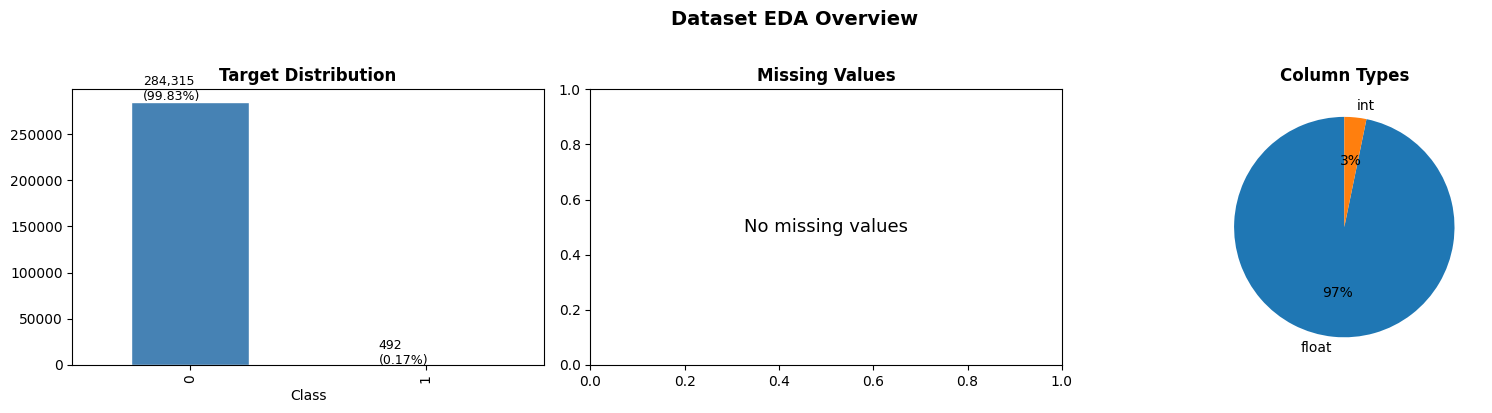

In [20]:
target_counts = df[TARGET_COLUMN].value_counts()
target_pct    = target_counts / len(df) * 100
imbalance     = target_counts.max() / target_counts.min()

print(f"Shape: {df.shape}  |  Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Duplicates: {df.duplicated().sum():,}")
print(f"\nTARGET '{TARGET_COLUMN}':")
for v in target_counts.index:
    print(f"  Class {v}: {target_counts[v]:>10,}  ({target_pct[v]:.3f}%)")
print(f"  Imbalance ratio: {imbalance:.1f}:1")

AUDIT["stages"]["eda"] = {
    "rows": int(len(df)), "cols": int(df.shape[1]),
    "imbalance_ratio": float(round(imbalance, 2))
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Target Distribution', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.2f}%)',
                     (p.get_x()+0.05, p.get_height()*1.01), fontsize=9)

miss_nz = df.isnull().mean().sort_values(ascending=False)
miss_nz = miss_nz[miss_nz > 0].head(30)
if len(miss_nz):
    miss_nz.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
    axes[1].axhline(MISSING_THRESHOLD, color='red', ls='--',
                    label=f'Drop threshold ({MISSING_THRESHOLD})')
    axes[1].set_title('Missing Values (top 30)', fontweight='bold')
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=13)
    axes[1].set_title('Missing Values', fontweight='bold')

dtype_map   = {'f':'float','i':'int','O':'object','b':'bool','M':'datetime','u':'uint'}
dtype_count = df.dtypes.apply(lambda x: x.kind).value_counts()
dtype_count.index = [dtype_map.get(k, k) for k in dtype_count.index]
dtype_count.plot(kind='pie', ax=axes[2], autopct='%1.0f%%', startangle=90)
axes[2].set_title('Column Types', fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('Dataset EDA Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/00_eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()

---
## ✂️ 3. Temporal / Stratified Three-Way Split
> **Train 70% | Val 15% | Holdout 15%**
> The holdout is locked — it is NOT touched until final evaluation in Stage 12.

In [21]:
X_all = df.drop(columns=[TARGET_COLUMN])
y_all = df[TARGET_COLUMN].copy()

if USE_TIME_SPLIT:
    n     = len(df)
    t_end = int(n * TRAIN_RATIO)
    v_end = int(n * (TRAIN_RATIO + VAL_RATIO))
    X_train, y_train = X_all.iloc[:t_end],    y_all.iloc[:t_end]
    X_val,   y_val   = X_all.iloc[t_end:v_end], y_all.iloc[t_end:v_end]
    X_hold,  y_hold  = X_all.iloc[v_end:],    y_all.iloc[v_end:]
    split_type = "Temporal chronological"
else:
    X_tv, X_hold, y_tv, y_hold = train_test_split(
        X_all, y_all, test_size=HOLDOUT_RATIO,
        stratify=y_all, random_state=RANDOM_STATE)
    val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac,
        stratify=y_tv, random_state=RANDOM_STATE)
    split_type = "Stratified random"

print(f"✅ Split: {split_type}")
for name, ys in [("Train", y_train),("Val", y_val),("Holdout", y_hold)]:
    pos = ys.sum()
    print(f"  {name:<8}: {len(ys):>8,} rows  |  fraud={pos:,} ({pos/len(ys)*100:.2f}%)")

AUDIT["stages"]["split"] = {
    "type": split_type, "train": int(len(y_train)),
    "val": int(len(y_val)), "holdout": int(len(y_hold))
}

✅ Split: Stratified random
  Train   :  199,364 rows  |  fraud=344 (0.17%)
  Val     :   42,721 rows  |  fraud=74 (0.17%)
  Holdout :   42,722 rows  |  fraud=74 (0.17%)


---
## 🔧 4. Leak-Safe Preprocessing Pipeline
> Transformers are **fit on train only** then applied to val/holdout.
> Missingness indicators are added **before** imputation — a blank field is a fraud signal.

In [22]:
class MissingnessIndicator(BaseEstimator, TransformerMixin):
    """Adds <col>_missing=1 for every column that had nulls in the training set."""
    def fit(self, X, y=None):
        self.missing_cols_ = [c for c in X.columns if X[c].isnull().any()]
        return self
    def transform(self, X):
        Xc = X.copy()
        for c in self.missing_cols_:
            Xc[f"{c}_missing"] = Xc[c].isnull().astype(np.int8)
        return Xc

# Step 1 — missingness indicators (fit on train)
miss_ind = MissingnessIndicator()
X_train_mi = miss_ind.fit_transform(X_train)
X_val_mi   = miss_ind.transform(X_val)
X_hold_mi  = miss_ind.transform(X_hold)
indicator_cols = [c for c in X_train_mi.columns if c.endswith('_missing')]
print(f"Added {len(indicator_cols)} missingness indicator columns")

# Step 2 — impute + encode per column type
cat_cols = X_train_mi.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train_mi.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_cols),
], remainder="drop")

X_train_proc = pd.DataFrame(
    preprocessor.fit_transform(X_train_mi), columns=num_cols + cat_cols)
X_val_proc   = pd.DataFrame(
    preprocessor.transform(X_val_mi),       columns=num_cols + cat_cols)
X_hold_proc  = pd.DataFrame(
    preprocessor.transform(X_hold_mi),      columns=num_cols + cat_cols)

for d in [X_train_proc, X_val_proc, X_hold_proc]:
    d.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_hold  = y_hold.reset_index(drop=True)

original_cols = X_train_proc.shape[1]
print(f"\n✅ Preprocessing complete: train shape = {X_train_proc.shape}")
AUDIT["stages"]["preprocessing"] = {
    "indicator_cols": len(indicator_cols),
    "total_features": original_cols
}

Added 0 missingness indicator columns

✅ Preprocessing complete: train shape = (199364, 30)


---
## 🚨 5. Leakage Audit
> Features with suspiciously high predictive power are flagged for manual inspection.
> **Do not auto-drop — investigate each flag before proceeding.**

Running leakage audit on training data...

LEAKAGE AUDIT RESULTS
  Flagged by |correlation| >0.7: 0
  Flagged by MI >0.5            : 0
  Total unique flagged                   : 0


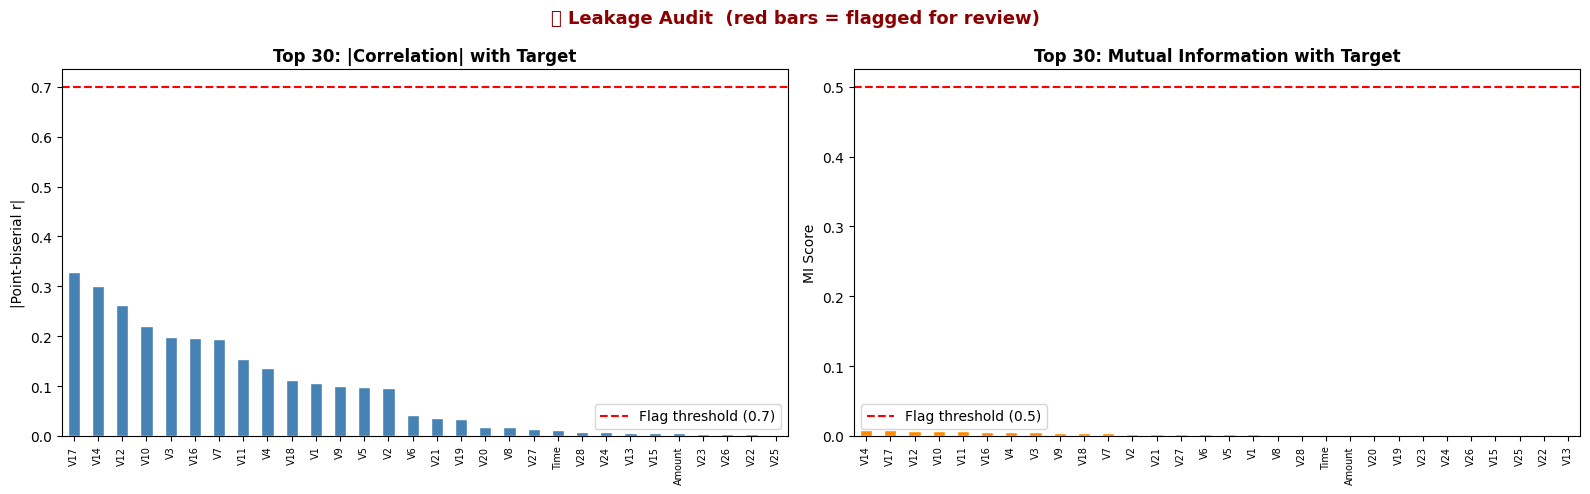

In [23]:
print("Running leakage audit on training data...")

corr_scores = {}
for col in X_train_proc.columns:
    try:
        r, _ = stats.pointbiserialr(X_train_proc[col].fillna(0), y_train)
        corr_scores[col] = abs(r)
    except Exception:
        corr_scores[col] = 0.0
corr_series = pd.Series(corr_scores).sort_values(ascending=False)

mi_raw = mutual_info_classif(X_train_proc, y_train, random_state=RANDOM_STATE, n_jobs=-1)
mi_raw_series = pd.Series(mi_raw, index=X_train_proc.columns).sort_values(ascending=False)

leak_corr  = corr_series[corr_series > LEAKAGE_CORR_THRESHOLD].index.tolist()
leak_mi    = mi_raw_series[mi_raw_series > LEAKAGE_MI_THRESHOLD].index.tolist()
leak_flags = list(set(leak_corr + leak_mi))

print(f"\nLEAKAGE AUDIT RESULTS")
print(f"  Flagged by |correlation| >{LEAKAGE_CORR_THRESHOLD}: {len(leak_corr)}")
print(f"  Flagged by MI >{LEAKAGE_MI_THRESHOLD}            : {len(leak_mi)}")
print(f"  Total unique flagged                   : {len(leak_flags)}")

if leak_flags:
    leak_df = pd.DataFrame({
        'feature':  leak_flags,
        'abs_corr': corr_series.reindex(leak_flags).values,
        'mi_score': mi_raw_series.reindex(leak_flags).values
    }).sort_values('abs_corr', ascending=False)
    print(f"\n  ⚠️  FLAGGED — review these before trusting any model:")
    print(leak_df.to_string(index=False))
    leak_df.to_csv(f"{OUTPUT_DIR}/LEAKAGE_FLAGS.csv", index=False)

AUDIT["stages"]["leakage"] = {
    "flagged": leak_flags,
    "corr_threshold": LEAKAGE_CORR_THRESHOLD,
    "mi_threshold": LEAKAGE_MI_THRESHOLD
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_n = 30

c_colors = ['tomato' if c in leak_flags else 'steelblue' for c in corr_series.head(top_n).index]
corr_series.head(top_n).plot(kind='bar', ax=axes[0], color=c_colors, edgecolor='white')
axes[0].axhline(LEAKAGE_CORR_THRESHOLD, color='red', ls='--', lw=1.5,
                label=f'Flag threshold ({LEAKAGE_CORR_THRESHOLD})')
axes[0].set_title(f'Top {top_n}: |Correlation| with Target', fontweight='bold')
axes[0].set_ylabel('|Point-biserial r|')
axes[0].legend(); axes[0].tick_params(axis='x', labelsize=7)

m_colors = ['tomato' if c in leak_flags else 'darkorange' for c in mi_raw_series.head(top_n).index]
mi_raw_series.head(top_n).plot(kind='bar', ax=axes[1], color=m_colors, edgecolor='white')
axes[1].axhline(LEAKAGE_MI_THRESHOLD, color='red', ls='--', lw=1.5,
                label=f'Flag threshold ({LEAKAGE_MI_THRESHOLD})')
axes[1].set_title(f'Top {top_n}: Mutual Information with Target', fontweight='bold')
axes[1].set_ylabel('MI Score')
axes[1].legend(); axes[1].tick_params(axis='x', labelsize=7)

plt.suptitle('🚨 Leakage Audit  (red bars = flagged for review)', fontsize=13,
             fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_leakage_audit.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🧹 Stage A — Pre-Filtering

In [24]:
dropped = {}

# A1. High missing (threshold from train, applied to all splits)
high_miss = X_train_proc.columns[X_train_proc.isnull().mean() > MISSING_THRESHOLD].tolist()
for d in [X_train_proc, X_val_proc, X_hold_proc]: d.drop(columns=high_miss, inplace=True)
dropped['high_missing'] = high_miss
print(f"[A1] Dropped {len(high_miss):>4} high-missing    → {X_train_proc.shape[1]} remain")

# A2. Near-zero variance (train only)
low_var = X_train_proc.columns[X_train_proc.var() < VARIANCE_THRESHOLD].tolist()
for d in [X_train_proc, X_val_proc, X_hold_proc]: d.drop(columns=low_var, inplace=True)
dropped['low_variance'] = low_var
print(f"[A2] Dropped {len(low_var):>4} low-variance     → {X_train_proc.shape[1]} remain")

# A3. High pairwise correlation (train only)
print(f"[A3] Computing pairwise correlation...")
upper    = X_train_proc.corr().abs()
upper    = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))
high_cor = [c for c in upper.columns if any(upper[c] > CORRELATION_THRESHOLD)]
for d in [X_train_proc, X_val_proc, X_hold_proc]: d.drop(columns=high_cor, inplace=True)
dropped['high_correlation'] = high_cor
print(f"     Dropped {len(high_cor):>4} high-corr        → {X_train_proc.shape[1]} remain")

after_A = X_train_proc.shape[1]
print(f"\n✅ Stage A: {original_cols} → {after_A}")
AUDIT["stages"]["stage_A"] = {
    "in": original_cols, "out": after_A,
    "dropped_missing": len(high_miss),
    "dropped_variance": len(low_var),
    "dropped_corr": len(high_cor)
}

[A1] Dropped    0 high-missing    → 30 remain
[A2] Dropped    0 low-variance     → 30 remain
[A3] Computing pairwise correlation...
     Dropped    0 high-corr        → 30 remain

✅ Stage A: 30 → 30


---
## 📊 Stage B — Cross-Validated Mutual Information
> MI computed on each fold separately and **averaged** — eliminates single-split noise.

Running 5-fold CV Mutual Information on 30 features...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

✅ Stage B: kept top 30 features by mean CV-MI


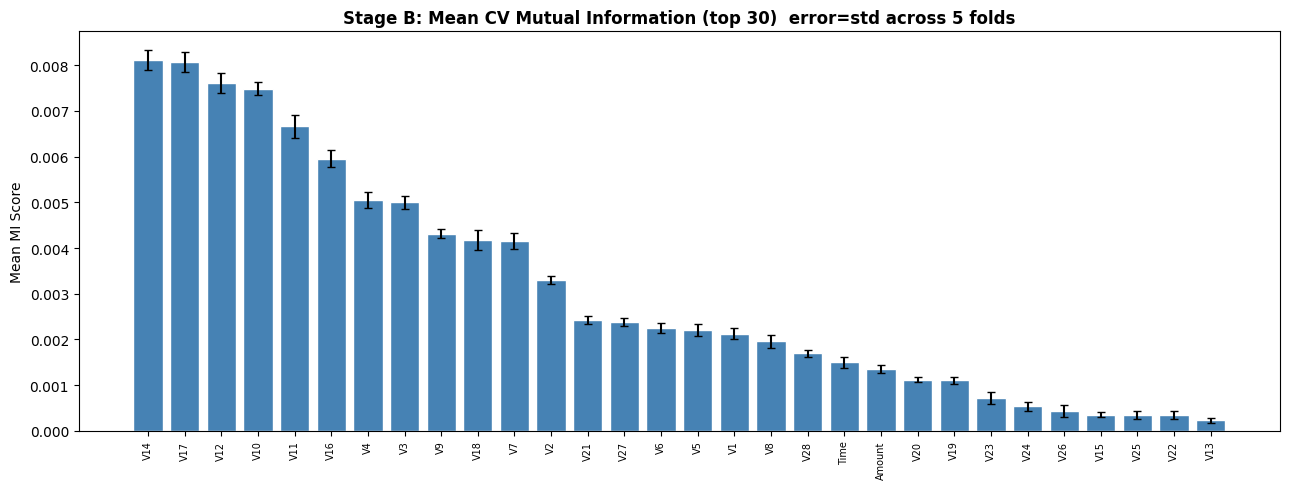

In [25]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Running {CV_FOLDS}-fold CV Mutual Information on {X_train_proc.shape[1]} features...")

mi_fold_scores = np.zeros((CV_FOLDS, X_train_proc.shape[1]))
for fold, (tr_idx, _) in enumerate(skf.split(X_train_proc, y_train)):
    mi_fold_scores[fold] = mutual_info_classif(
        X_train_proc.iloc[tr_idx], y_train.iloc[tr_idx],
        random_state=RANDOM_STATE, n_jobs=-1)
    print(f"  Fold {fold+1}/{CV_FOLDS} done")

mi_cv = pd.DataFrame({
    'feature': X_train_proc.columns,
    'mi_mean': mi_fold_scores.mean(axis=0),
    'mi_std':  mi_fold_scores.std(axis=0)
}).sort_values('mi_mean', ascending=False).reset_index(drop=True)

top_B        = min(MI_TOP_K, len(mi_cv))
mi_selected  = mi_cv.head(top_B)['feature'].tolist()
mi_cv.to_csv(f"{OUTPUT_DIR}/stageB_mi_cv.csv", index=False)
print(f"\n✅ Stage B: kept top {top_B} features by mean CV-MI")
AUDIT["stages"]["stage_B"] = {"in": after_A, "out": top_B}

fig, ax = plt.subplots(figsize=(13, 5))
pn = min(50, top_B); tm = mi_cv.head(pn)
ax.bar(range(pn), tm['mi_mean'], color='steelblue', yerr=tm['mi_std'], capsize=3, edgecolor='white')
ax.set_xticks(range(pn)); ax.set_xticklabels(tm['feature'], rotation=90, fontsize=7)
ax.set_title(f'Stage B: Mean CV Mutual Information (top {pn})  error=std across {CV_FOLDS} folds',
             fontweight='bold')
ax.set_ylabel('Mean MI Score')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_stageB_mi_cv.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🌲 Stage C — Cross-Validated LightGBM + Permutation Importance
> One model per fold. Gain importance and permutation importance **averaged** across all folds.

In [26]:
X_B = X_train_proc[mi_selected].copy()
print(f"Running {CV_FOLDS}-fold CV LightGBM on {len(mi_selected)} features...")

fold_lgbm = np.zeros((CV_FOLDS, len(mi_selected)))
fold_perm = np.zeros((CV_FOLDS, len(mi_selected)))
fold_pr   = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_B, y_train)):
    Xtr, Xvl = X_B.iloc[tr_idx], X_B.iloc[vl_idx]
    ytr, yvl = y_train.iloc[tr_idx], y_train.iloc[vl_idx]
    spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)

    m = lgb.LGBMClassifier(**{**LGBM_PARAMS, "scale_pos_weight": spw})
    m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])

    fold_lgbm[fold] = m.feature_importances_
    perm = permutation_importance(m, Xvl, yvl, n_repeats=PERMUTATION_REPEATS,
                                   scoring='average_precision',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    fold_perm[fold] = perm.importances_mean
    pr = average_precision_score(yvl, m.predict_proba(Xvl)[:,1])
    fold_pr.append(pr)
    print(f"  Fold {fold+1}/{CV_FOLDS}  PR-AUC={pr:.4f}  spw={spw:.1f}")

lgbm_mean = pd.Series(fold_lgbm.mean(axis=0), index=mi_selected)
lgbm_std  = pd.Series(fold_lgbm.std(axis=0),  index=mi_selected)
perm_mean = pd.Series(fold_perm.mean(axis=0),  index=mi_selected)
perm_std  = pd.Series(fold_perm.std(axis=0),   index=mi_selected)

avg_rank      = ((lgbm_mean.rank(ascending=False) + perm_mean.rank(ascending=False)) / 2).sort_values()
top_C         = min(LGBM_TOP_K, len(avg_rank))
stage_C_feats = avg_rank.head(top_C).index.tolist()

cv_pr_mean = np.mean(fold_pr); cv_pr_std = np.std(fold_pr)
print(f"\n✅ Stage C: {top_B} → {top_C} features  |  CV PR-AUC: {cv_pr_mean:.4f} ± {cv_pr_std:.4f}")
AUDIT["stages"]["stage_C"] = {
    "in": top_B, "out": top_C,
    "cv_pr_auc_mean": float(round(cv_pr_mean, 4)),
    "cv_pr_auc_std":  float(round(cv_pr_std, 4))
}

pd.DataFrame({
    'feature':    mi_selected,
    'lgbm_mean':  lgbm_mean.values, 'lgbm_std': lgbm_std.values,
    'perm_mean':  perm_mean.values, 'perm_std': perm_std.values,
    'avg_rank':   avg_rank.reindex(mi_selected).values
}).sort_values('avg_rank').to_csv(f"{OUTPUT_DIR}/stageC_cv_importance.csv", index=False)

Running 5-fold CV LightGBM on 30 features...
  Fold 1/5  PR-AUC=0.7185  spw=579.0
  Fold 2/5  PR-AUC=0.7569  spw=579.0
  Fold 3/5  PR-AUC=0.6955  spw=579.0
  Fold 4/5  PR-AUC=0.7857  spw=579.0
  Fold 5/5  PR-AUC=0.1566  spw=576.9

✅ Stage C: 30 → 30 features  |  CV PR-AUC: 0.6226 ± 0.2351


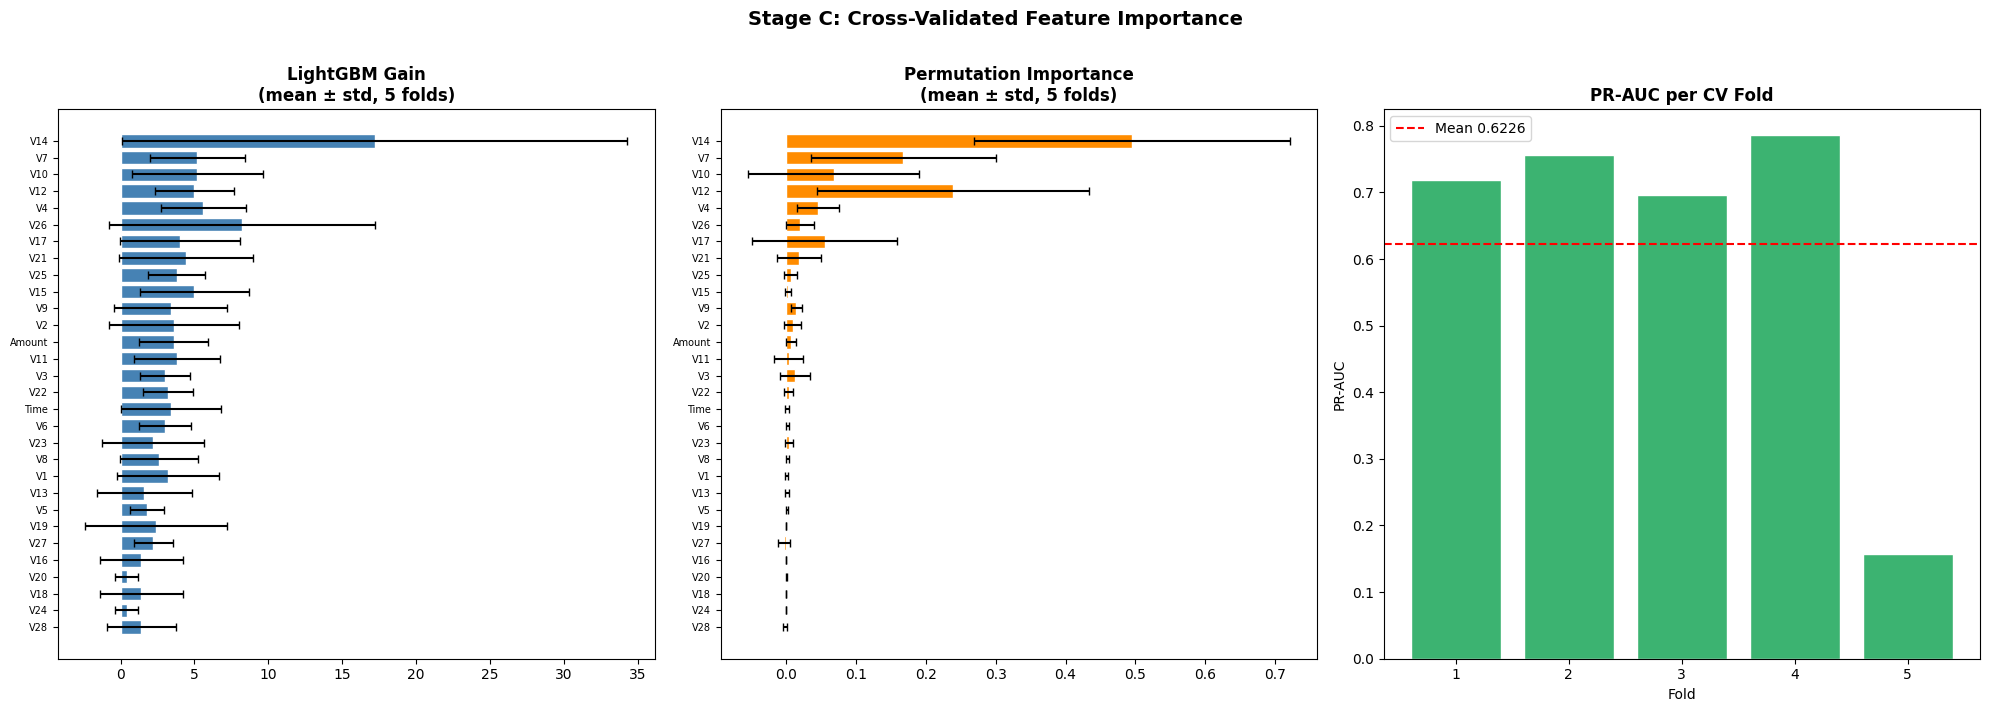

In [27]:
pn = min(40, top_C); idx = avg_rank.head(pn).index
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].barh(range(pn), lgbm_mean.reindex(idx).values, xerr=lgbm_std.reindex(idx).values,
             color='steelblue', edgecolor='white', capsize=3)
axes[0].set_yticks(range(pn)); axes[0].set_yticklabels(idx, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_title(f'LightGBM Gain\n(mean ± std, {CV_FOLDS} folds)', fontweight='bold')

axes[1].barh(range(pn), perm_mean.reindex(idx).values, xerr=perm_std.reindex(idx).values,
             color='darkorange', edgecolor='white', capsize=3)
axes[1].set_yticks(range(pn)); axes[1].set_yticklabels(idx, fontsize=7)
axes[1].invert_yaxis()
axes[1].set_title(f'Permutation Importance\n(mean ± std, {CV_FOLDS} folds)', fontweight='bold')

axes[2].bar(range(1, CV_FOLDS+1), fold_pr, color='mediumseagreen', edgecolor='white')
axes[2].axhline(cv_pr_mean, color='red', ls='--', lw=1.5, label=f'Mean {cv_pr_mean:.4f}')
axes[2].set_title('PR-AUC per CV Fold', fontweight='bold')
axes[2].set_xlabel('Fold'); axes[2].set_ylabel('PR-AUC'); axes[2].legend()

plt.suptitle('Stage C: Cross-Validated Feature Importance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_stageC_cv_importance.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🔁 Stage D — Feature Stability Check (Bootstrap)
> Features with high rank variance across bootstrap samples are unstable noise — drop them.

Running 20 bootstrap rounds on 30 features...
  Round 5/20
  Round 10/20
  Round 15/20
  Round 20/20

✅ Stage D: 30 → 30 stable features
   Unstable (dropped): 0


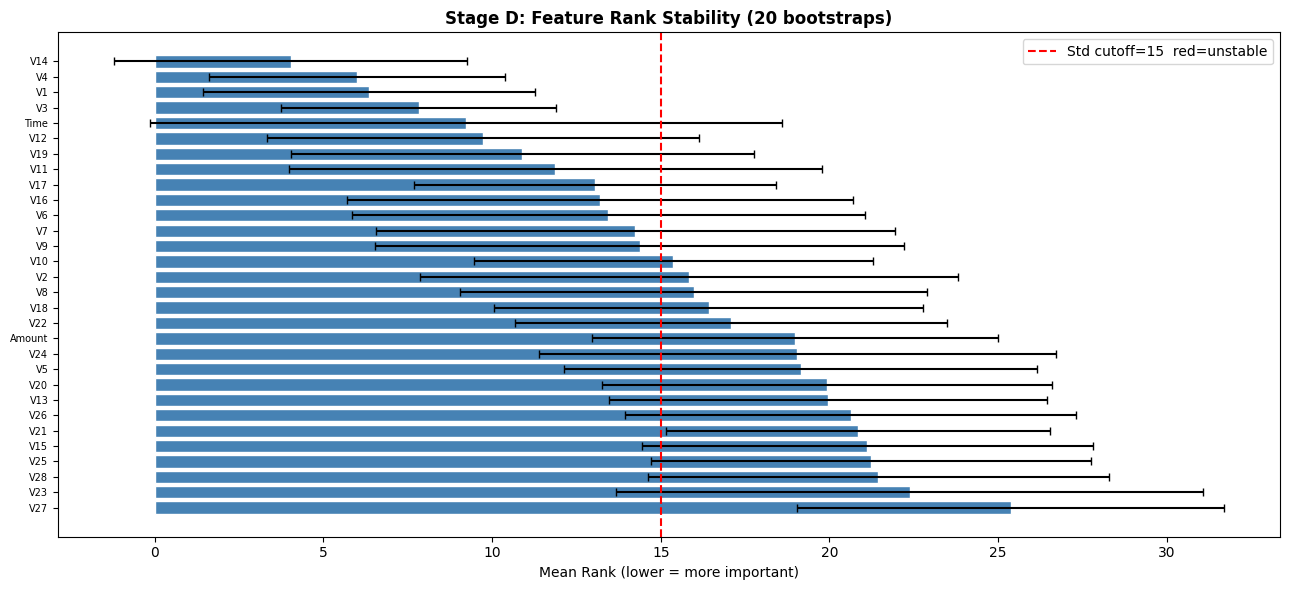

In [28]:
X_C  = X_train_proc[stage_C_feats].copy()
spw_g = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
params_boot = {**LGBM_PARAMS, "scale_pos_weight": spw_g, "n_estimators": 200}
print(f"Running {BOOTSTRAP_ROUNDS} bootstrap rounds on {len(stage_C_feats)} features...")

boot_ranks = np.zeros((BOOTSTRAP_ROUNDS, len(stage_C_feats)))
for b in range(BOOTSTRAP_ROUNDS):
    idx = X_C.sample(frac=BOOTSTRAP_SAMPLE_FRAC, replace=True, random_state=b).index
    m   = lgb.LGBMClassifier(**params_boot)
    m.fit(X_C.loc[idx], y_train.loc[idx], callbacks=[lgb.log_evaluation(period=-1)])
    boot_ranks[b] = pd.Series(m.feature_importances_, index=stage_C_feats).rank(ascending=False).values
    if (b+1) % 5 == 0: print(f"  Round {b+1}/{BOOTSTRAP_ROUNDS}")

stab_df = pd.DataFrame({
    'feature':   stage_C_feats,
    'rank_mean': boot_ranks.mean(axis=0),
    'rank_std':  boot_ranks.std(axis=0)
}).sort_values('rank_mean')

stable_feats   = stab_df[stab_df['rank_std'] <= STABILITY_STD_CUTOFF]['feature'].tolist()
unstable_feats = stab_df[stab_df['rank_std'] >  STABILITY_STD_CUTOFF]['feature'].tolist()
stab_df.to_csv(f"{OUTPUT_DIR}/stageD_stability.csv", index=False)

print(f"\n✅ Stage D: {top_C} → {len(stable_feats)} stable features")
print(f"   Unstable (dropped): {len(unstable_feats)}")
AUDIT["stages"]["stage_D"] = {
    "in": top_C, "out": len(stable_feats), "unstable": unstable_feats
}

pn = min(40, len(stage_C_feats)); sp = stab_df.head(pn)
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['tomato' if f in unstable_feats else 'steelblue' for f in sp['feature']]
ax.barh(range(pn), sp['rank_mean'], xerr=sp['rank_std'], color=colors,
        edgecolor='white', capsize=3)
ax.set_yticks(range(pn)); ax.set_yticklabels(sp['feature'], fontsize=7)
ax.axvline(STABILITY_STD_CUTOFF, color='red', ls='--', lw=1.5,
           label=f'Std cutoff={STABILITY_STD_CUTOFF}  red=unstable')
ax.invert_yaxis()
ax.set_title(f'Stage D: Feature Rank Stability ({BOOTSTRAP_ROUNDS} bootstraps)',
             fontweight='bold')
ax.set_xlabel('Mean Rank (lower = more important)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_stageD_stability.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Stage E — SHAP Validation
> Retrain a clean model on stable features only, then compute SHAP for final ranking and direction analysis.

In [29]:
X_tr_s = X_train_proc[stable_feats]
X_vl_s = X_val_proc[stable_feats]
spw    = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"Retraining LightGBM on {len(stable_feats)} stable features...")
model_shap = lgb.LGBMClassifier(**{**LGBM_PARAMS, "scale_pos_weight": spw})
model_shap.fit(X_tr_s, y_train, eval_set=[(X_vl_s, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False),
                          lgb.log_evaluation(period=-1)])

y_prob_vl   = model_shap.predict_proba(X_vl_s)[:,1]
pr_auc_vl   = average_precision_score(y_val, y_prob_vl)
roc_auc_vl  = roc_auc_score(y_val, y_prob_vl)
print(f"   Val PR-AUC={pr_auc_vl:.4f}  ROC-AUC={roc_auc_vl:.4f}")
print(f"   (CV baseline: {cv_pr_mean:.4f} ± {cv_pr_std:.4f})")

n_shap   = min(SHAP_SAMPLE_SIZE, len(X_vl_s))
X_shap   = X_vl_s.sample(n_shap, random_state=RANDOM_STATE)
print(f"\nComputing SHAP on {n_shap:,} samples x {len(stable_feats)} features...")

explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap)
sv          = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_imp = pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
print("✅ SHAP values computed.")

Retraining LightGBM on 30 stable features...
   Val PR-AUC=0.1157  ROC-AUC=0.8427
   (CV baseline: 0.6226 ± 0.2351)

Computing SHAP on 5,000 samples x 30 features...
✅ SHAP values computed.


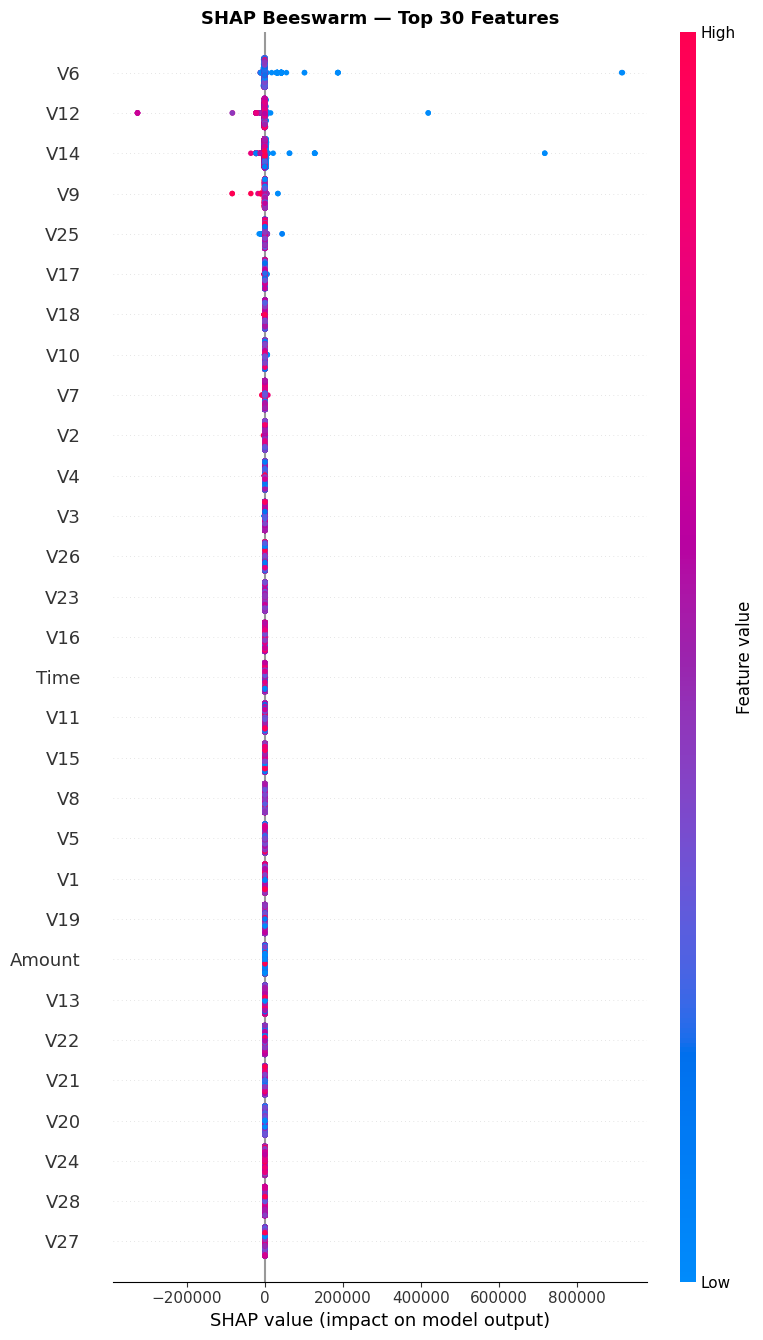

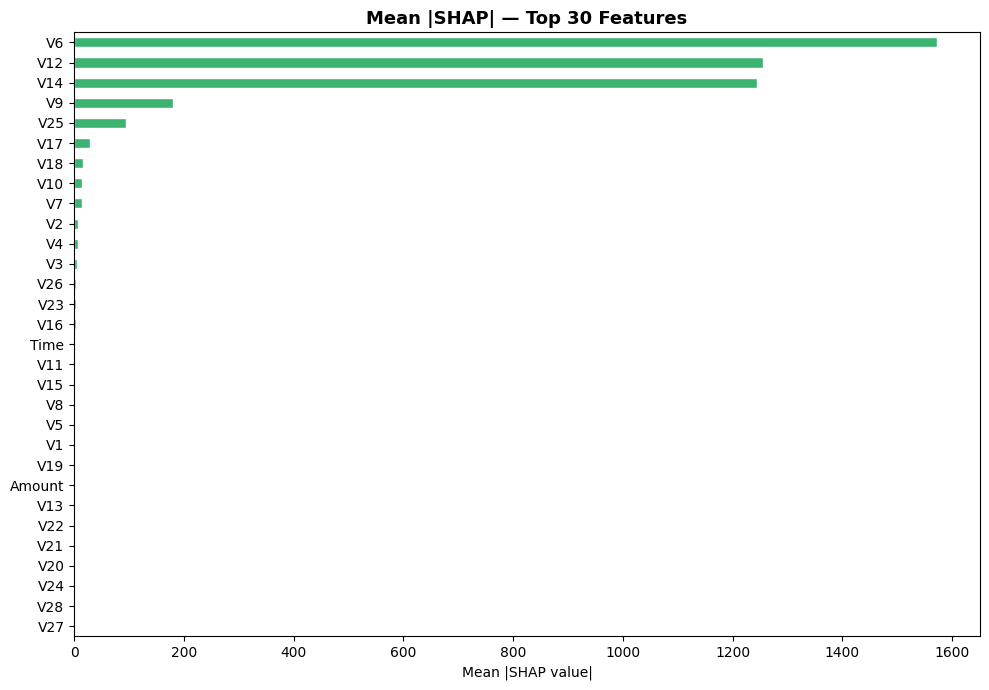

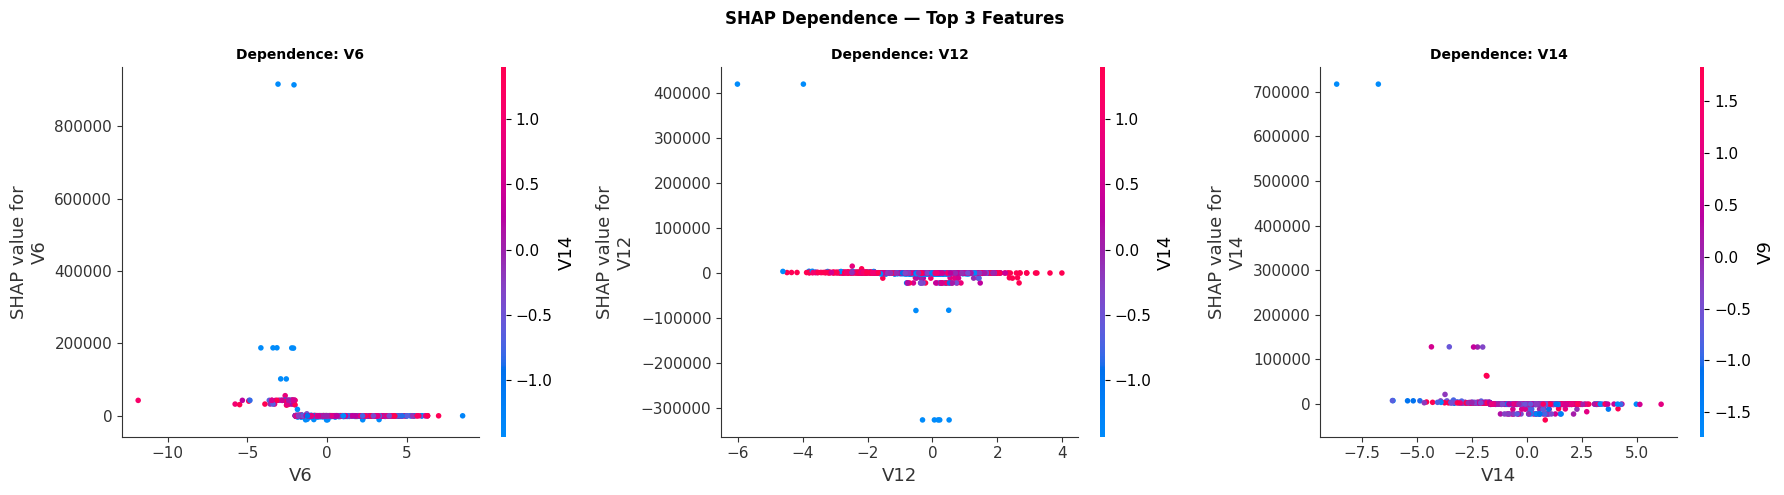

💾 SHAP saved.


In [30]:
# Beeswarm
plt.figure(figsize=(10, 9))
shap.summary_plot(sv, X_shap, max_display=SHAP_TOP_K, show=False)
plt.title(f"SHAP Beeswarm — Top {SHAP_TOP_K} Features", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05a_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar
plt.figure(figsize=(10, 7))
shap_imp.head(SHAP_TOP_K).plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.gca().invert_yaxis()
plt.title(f"Mean |SHAP| — Top {SHAP_TOP_K} Features", fontweight='bold', fontsize=13)
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05b_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# Dependence for top 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(shap_imp.index[:3]):
    shap.dependence_plot(feat, sv, X_shap, ax=axes[i], show=False)
    axes[i].set_title(f"Dependence: {feat}", fontweight='bold', fontsize=10)
plt.suptitle('SHAP Dependence — Top 3 Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05c_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

shap_imp.reset_index().rename(columns={'index':'feature', 0:'mean_abs_shap'})\
        .to_csv(f"{OUTPUT_DIR}/stageE_shap_importance.csv", index=False)
print("💾 SHAP saved.")

Cliff method used     : ratio (6.9x drop)
Cliff position        : rank 3
Last feature kept     : V14  (SHAP=1243.78)
First feature dropped : V9  (SHAP=179.38)

→ Recommended: keep top 3 features
→ Features: ['V6', 'V12', 'V14']


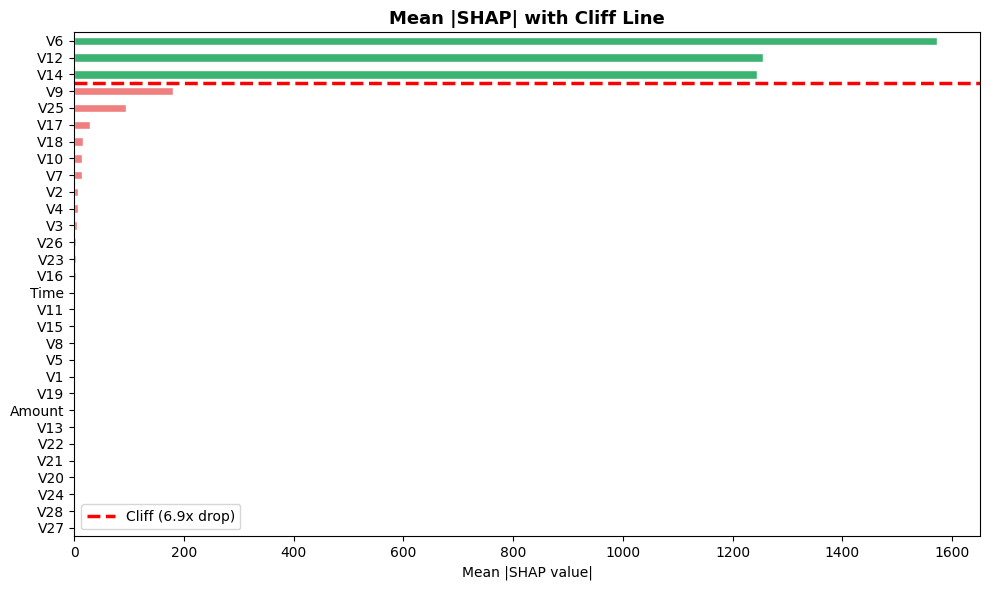

In [31]:
# ── Smarter cliff detection ───────────────────────────────────
shap_vals = shap_imp.values

# Method 1: Ratio — but require a MINIMUM drop ratio (e.g. 5x)
MIN_CLIFF_RATIO = 5.0
ratios = shap_vals[:-1] / np.maximum(shap_vals[1:], 1e-9)
significant = np.where(ratios >= MIN_CLIFF_RATIO)[0]

if len(significant):
    cliff_idx = significant[0]  # first cliff that meets threshold
    method = f"ratio ({ratios[cliff_idx]:.1f}x drop)"
else:
    # Method 2: fallback — find the elbow using cumulative explained "importance"
    cumulative = np.cumsum(shap_vals) / shap_vals.sum()
    cliff_idx  = np.argmax(cumulative >= 0.80)  # features explaining 80% of total SHAP
    method = "80% cumulative SHAP"

print(f"Cliff method used     : {method}")
print(f"Cliff position        : rank {cliff_idx + 1}")
print(f"Last feature kept     : {shap_imp.index[cliff_idx]}  "
      f"(SHAP={shap_vals[cliff_idx]:.2f})")
print(f"First feature dropped : {shap_imp.index[cliff_idx+1]}  "
      f"(SHAP={shap_vals[cliff_idx+1]:.2f})")
print(f"\n→ Recommended: keep top {cliff_idx + 1} features")
features_above_cliff = shap_imp.index[:cliff_idx + 1].tolist()
print(f"→ Features: {features_above_cliff}")


# Plot with cliff line marked
plt.figure(figsize=(10, 6))
colors = ['mediumseagreen' if i <= cliff_idx else 'lightcoral'
          for i in range(len(shap_imp))]
shap_imp.head(SHAP_TOP_K).plot(kind='barh', color=colors[:SHAP_TOP_K],
                                edgecolor='white')
plt.gca().invert_yaxis()

# Replace the label in the plot
if ratios[cliff_idx] >= MIN_CLIFF_RATIO:
    legend_label = f"Cliff ({ratios[cliff_idx]:.1f}x drop)"
else:
    legend_label = f"80% cumulative SHAP cut  (no sharp cliff found — ratio only {ratios[cliff_idx]:.1f}x)"

plt.axhline(cliff_idx + 0.5, color='red', linewidth=2.5,
            linestyle='--', label=legend_label)
plt.title('Mean |SHAP| with Cliff Line', fontweight='bold', fontsize=13)
plt.xlabel('Mean |SHAP value|')
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_cliff.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🧑‍💼 Stage F — Business Logic Review Checkpoint
> **Human-in-the-loop.** Review the table, check leakage flags and SHAP directions, then set exclusions below.

In [32]:
feat_idx = list(X_shap.columns)
review_df = pd.DataFrame({
    'shap_rank':      range(1, len(shap_imp)+1),
    'feature':        shap_imp.index,
    'mean_abs_shap':  shap_imp.values,
    'lgbm_cv_mean':   lgbm_mean.reindex(shap_imp.index).values,
    'perm_cv_mean':   perm_mean.reindex(shap_imp.index).values,
    'mi_cv_mean':     mi_cv.set_index('feature')['mi_mean'].reindex(shap_imp.index).values,
    'rank_std_boot':  stab_df.set_index('feature')['rank_std'].reindex(shap_imp.index).values,
    'leakage_flag':   ['⚠️ CHECK' if f in leak_flags else 'ok' for f in shap_imp.index],
    'shap_direction': [
        '→ fraud' if sv[:, feat_idx.index(f)].mean() > 0 else '→ legit'
        for f in shap_imp.index
    ],
})

print("BUSINESS LOGIC REVIEW TABLE")
print(review_df.to_string(index=False))
print()
print("ACTION REQUIRED:")
print("  1. Verify each ⚠️ CHECK feature is computable at prediction time (not post-transaction)")
print("  2. Confirm SHAP direction matches business intuition")
print("  3. Add domain exclusions to FEATURES_TO_EXCLUDE below")
review_df.to_csv(f"{OUTPUT_DIR}/REVIEW_TABLE.csv", index=False)

BUSINESS LOGIC REVIEW TABLE
 shap_rank feature  mean_abs_shap  lgbm_cv_mean  perm_cv_mean  mi_cv_mean  rank_std_boot leakage_flag shap_direction
         1      V6    1572.442680           3.0      0.001732    0.002248       7.594241           ok        → fraud
         2     V12    1254.786140           5.0      0.238503    0.007606       6.402099           ok        → legit
         3     V14    1243.777746          17.2      0.495358    0.008114       5.245176           ok        → legit
         4      V9     179.377327           3.4      0.014718    0.004316       7.834020           ok        → legit
         5     V25      94.150875           3.8      0.006953    0.000348       6.518196           ok        → fraud
         6     V17      29.329449           4.0      0.055181    0.008078       5.370987           ok        → fraud
         7     V18      15.667100           1.4      0.000004    0.004176       6.358606           ok        → legit
         8     V10      14.924986   

In [33]:
# ================================================================
#  HUMAN CHECKPOINT — Edit after reviewing the table above
# ================================================================

# List any features confirmed as leakage or failing business logic
FEATURES_TO_EXCLUDE = []   # e.g. ['V1'] if confirmed leaked

# Drop features whose mean |SHAP| is below this (look for the cliff in the bar chart)
SHAP_CUTOFF = 0.0          # e.g. 1.0 to drop near-zero-impact features

# ================================================================
confirmed_features = [
    f for f in shap_imp.index
    if f not in FEATURES_TO_EXCLUDE and shap_imp[f] > SHAP_CUTOFF
]
print(f"✅ Confirmed {len(confirmed_features)} final features")
print(f"   Excluded by review : {FEATURES_TO_EXCLUDE}")
print(f"   Final set: {confirmed_features}")

AUDIT["stages"]["stage_EF"] = {
    "in": len(stable_feats), "out": len(confirmed_features),
    "excluded": FEATURES_TO_EXCLUDE, "shap_cutoff": SHAP_CUTOFF,
    "final_features": confirmed_features
}

✅ Confirmed 29 final features
   Excluded by review : []
   Final set: ['V6', 'V12', 'V14', 'V9', 'V25', 'V17', 'V18', 'V10', 'V7', 'V2', 'V4', 'V3', 'V26', 'V23', 'V16', 'Time', 'V11', 'V15', 'V8', 'V5', 'V1', 'V19', 'Amount', 'V13', 'V22', 'V21', 'V20', 'V24', 'V28']


---
## 🎯 12. Final Model + Threshold Tuning


Threshold tuning (target recall >= 0.8):
  Optimal threshold : 1.0000
  Precision         : 0.0344
  Recall            : 0.9189


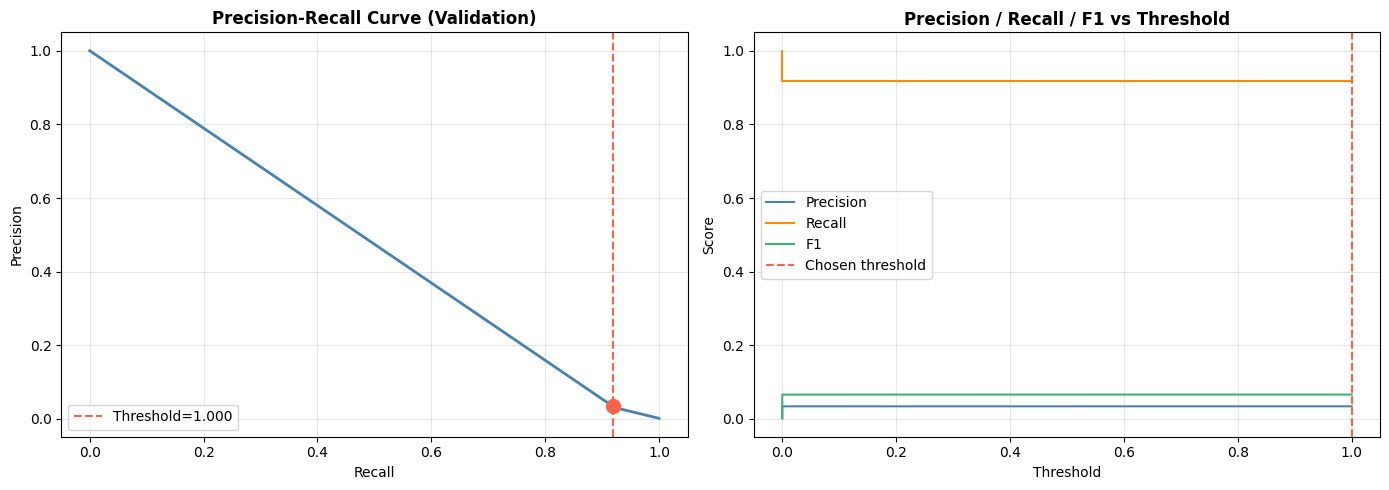

In [34]:
X_tr_f = X_train_proc[confirmed_features]
X_vl_f = X_val_proc[confirmed_features]
X_ho_f = X_hold_proc[confirmed_features]
spw    = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

final_model = lgb.LGBMClassifier(**{**LGBM_PARAMS, "scale_pos_weight": spw})
final_model.fit(X_tr_f, y_train, eval_set=[(X_vl_f, y_val)],
                callbacks=[lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(period=-1)])

# Threshold tuning on validation
y_prob_vl2 = final_model.predict_proba(X_vl_f)[:,1]
prec, rec, thresholds = precision_recall_curve(y_val, y_prob_vl2)

valid_idx = np.where(rec[:-1] >= TARGET_RECALL)[0]
if len(valid_idx):
    best_idx    = valid_idx[np.argmax(prec[valid_idx])]
    best_thresh = float(thresholds[best_idx])
    best_prec   = float(prec[best_idx])
    best_rec    = float(rec[best_idx])
else:
    best_thresh = 0.5; best_prec = best_rec = float('nan')
    print(f"⚠️  Could not achieve target recall {TARGET_RECALL} — defaulting to 0.5")

print(f"\nThreshold tuning (target recall >= {TARGET_RECALL}):")
print(f"  Optimal threshold : {best_thresh:.4f}")
print(f"  Precision         : {best_prec:.4f}")
print(f"  Recall            : {best_rec:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rec, prec, color='steelblue', lw=2)
axes[0].axvline(best_rec, color='tomato', ls='--', lw=1.5,
                label=f'Threshold={best_thresh:.3f}')
axes[0].scatter([best_rec], [best_prec], color='tomato', s=100, zorder=5)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Validation)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
axes[1].plot(thresholds, prec[:-1], label='Precision', color='steelblue')
axes[1].plot(thresholds, rec[:-1],  label='Recall',    color='darkorange')
axes[1].plot(thresholds, f1s,       label='F1',        color='mediumseagreen')
axes[1].axvline(best_thresh, color='tomato', ls='--', lw=1.5, label='Chosen threshold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_threshold_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# 1. Check predicted probability spread
probs = final_model.predict_proba(X_vl_f)[:,1]
print(f"Min prob  : {probs.min():.6f}")
print(f"Max prob  : {probs.max():.6f}")
print(f"Mean prob : {probs.mean():.6f}")
print(f"Unique    : {len(np.unique(probs))}")

# 2. Check V241 leakage
print(f"\nV241 correlation with target: {df['V241'].corr(df[TARGET_COLUMN]):.4f}")
print(df.groupby(TARGET_COLUMN)['V241'].agg(['mean','std','min','max']))

# 3. Check class balance in splits
for name, y in [('Train', y_train), ('Val', y_val)]:
    print(f"\n{name}: {y.value_counts().to_dict()}")

Min prob  : 0.000000
Max prob  : 1.000000
Mean prob : 0.046308
Unique    : 139


KeyError: 'V241'

In [ ]:
# HOLDOUT EVALUATION — final score, never used before this step
print("=" * 55)
print("HOLDOUT EVALUATION  (locked set — first time touched)")
print("=" * 55)

y_prob_ho = final_model.predict_proba(X_ho_f)[:,1]
y_pred_ho = (y_prob_ho >= best_thresh).astype(int)
ho_pr     = average_precision_score(y_hold, y_prob_ho)
ho_roc    = roc_auc_score(y_hold, y_prob_ho)

print(f"  PR-AUC   : {ho_pr:.4f}")
print(f"  ROC-AUC  : {ho_roc:.4f}")
print(f"  Threshold: {best_thresh:.4f}")
print()
print(classification_report(y_hold, y_pred_ho, digits=4))

cm = confusion_matrix(y_hold, y_pred_ho)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
ax.set_title(f'Holdout Confusion Matrix\nPR-AUC={ho_pr:.4f}  thresh={best_thresh:.4f}',
             fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_holdout_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

AUDIT["stages"]["final_model"] = {
    "threshold": round(best_thresh, 4),
    "holdout_pr_auc":  round(ho_pr,  4),
    "holdout_roc_auc": round(ho_roc, 4)
}

---
## 📡 13. Feature Drift Monitoring Baseline
> Export statistical profile of each final feature from training data.
> Use in production to detect distribution shift before it degrades model performance.

In [ ]:
drift = []
for feat in confirmed_features:
    col = X_train_proc[feat]
    drift.append({
        'feature':   feat,
        'mean':      float(col.mean()),
        'std':       float(col.std()),
        'min':       float(col.min()),
        'p01':       float(col.quantile(0.01)),
        'p25':       float(col.quantile(0.25)),
        'p50':       float(col.quantile(0.50)),
        'p75':       float(col.quantile(0.75)),
        'p99':       float(col.quantile(0.99)),
        'max':       float(col.max()),
        'null_rate': float(col.isnull().mean()),
        'n_unique':  int(col.nunique()),
    })

drift_df = pd.DataFrame(drift)
drift_df.to_csv(f"{OUTPUT_DIR}/DRIFT_BASELINE.csv", index=False)
print(f"✅ Drift baseline: {len(confirmed_features)} features x 11 statistics")
print(f"   Saved to {OUTPUT_DIR}/DRIFT_BASELINE.csv")
print()
print("Production usage:")
print("  Load DRIFT_BASELINE.csv and compare to incoming batch.")
print("  Alert if: |mean_shift| > 2*std  OR  null_rate changes by >0.05")
drift_df.head()

---
## 📦 14. Final Summary, Funnel & Audit Trail

In [ ]:
funnel = [
    ('Raw',             original_cols),
    ('A: Pre-filter',   after_A),
    ('B: CV MI',        top_B),
    ('C: CV LGBM',      top_C),
    ('D: Bootstrap',    len(stable_feats)),
    ('E+F: SHAP+Review',len(confirmed_features)),
]
labels, counts = zip(*funnel)
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts)*0.01,
            str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)
for i in range(1, len(counts)):
    pct = (1 - counts[i]/counts[i-1])*100
    ax.annotate(f'-{pct:.0f}%', xy=((i-0.5), max(counts)*0.55),
                ha='center', color='gray', fontsize=9)
ax.set_title('Gold-Standard Feature Reduction Funnel', fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Features')
ax.set_ylim(0, max(counts)*1.18)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_reduction_funnel.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"{'='*60}")
print("PIPELINE SUMMARY")
print(f"{'='*60}")
for lbl, cnt in funnel:
    print(f"  {lbl:<25}: {cnt:>6} features")
pct_removed = (1 - len(confirmed_features)/original_cols)*100
print(f"  {'Total reduction':<25}: {original_cols} → {len(confirmed_features)}  ({pct_removed:.1f}% removed)")
print()
print(f"  CV PR-AUC        : {cv_pr_mean:.4f} ± {cv_pr_std:.4f}")
print(f"  Val PR-AUC (SHAP): {pr_auc_vl:.4f}")
print(f"  Holdout PR-AUC   : {ho_pr:.4f}  ← final score")
print(f"  Holdout ROC-AUC  : {ho_roc:.4f}")
print(f"  Decision threshold: {best_thresh:.4f}")
print(f"  Leakage flags    : {len(leak_flags)}")

In [ ]:
# Reduced dataset export
X_full_final = pd.concat([
    X_train_proc[confirmed_features],
    X_val_proc[confirmed_features],
    X_hold_proc[confirmed_features]
], ignore_index=True)
X_full_final[TARGET_COLUMN] = pd.concat([y_train, y_val, y_hold], ignore_index=True)
X_full_final.to_csv(f"{OUTPUT_DIR}/dataset_final_features.csv", index=False)

# Audit trail
AUDIT["final_summary"] = {
    "original_features":  original_cols,
    "final_features":     len(confirmed_features),
    "reduction_pct":      round(pct_removed, 1),
    "cv_pr_auc":          f"{cv_pr_mean:.4f} +/- {cv_pr_std:.4f}",
    "holdout_pr_auc":     round(ho_pr,  4),
    "holdout_roc_auc":    round(ho_roc, 4),
    "decision_threshold": round(best_thresh, 4),
    "leakage_flags":      leak_flags,
    "confirmed_features": confirmed_features
}
with open(f"{OUTPUT_DIR}/AUDIT_TRAIL.json", "w") as f:
    json.dump(AUDIT, f, indent=2)

print(f"\n📁 OUTPUT FILES ({OUTPUT_DIR}/):")
manifest = [
    ("00_eda_overview.png",          "EDA charts"),
    ("01_leakage_audit.png",         "Leakage audit plots"),
    ("02_stageB_mi_cv.png",          "CV Mutual Information"),
    ("03_stageC_cv_importance.png",  "CV LGBM + permutation"),
    ("04_stageD_stability.png",      "Bootstrap stability"),
    ("05a_shap_beeswarm.png",        "SHAP beeswarm"),
    ("05b_shap_bar.png",             "SHAP bar"),
    ("05c_shap_dependence.png",      "SHAP dependence top 3"),
    ("06_threshold_tuning.png",      "PR curve + threshold sweep"),
    ("07_holdout_confusion.png",     "Holdout confusion matrix"),
    ("08_reduction_funnel.png",      "Feature reduction funnel"),
    ("LEAKAGE_FLAGS.csv",            "Leakage review flags"),
    ("REVIEW_TABLE.csv",             "Business logic review"),
    ("DRIFT_BASELINE.csv",           "Production drift baseline"),
    ("dataset_final_features.csv",   "Reduced dataset"),
    ("AUDIT_TRAIL.json",             "Full pipeline audit trail"),
]
for fname, desc in manifest:
    fp   = Path(OUTPUT_DIR) / fname
    size = fp.stat().st_size/1024 if fp.exists() else 0
    flag = '✅' if fp.exists() else '❌'
    print(f"  {flag} {fname:<42} {size:>7.1f} KB  — {desc}")